In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import numpy as np

In [8]:
data_set=pd.read_csv('online_shoppers_intention.csv')
data_set.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
data_set.shape

(53070, 11)

In [4]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53070 entries, 0 to 53069
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         53070 non-null  object
 1   More Info     53070 non-null  object
 2   Price         53070 non-null  object
 3   Serviced      53070 non-null  int64 
 4   Newly Built   53070 non-null  int64 
 5   Furnished     53070 non-null  int64 
 6   Bedrooms      53070 non-null  object
 7   Bathrooms     53070 non-null  object
 8   Toilets       53070 non-null  object
 9   City          53070 non-null  object
 10  Neighborhood  53070 non-null  object
dtypes: int64(3), object(8)
memory usage: 4.5+ MB


In [5]:
data_set.describe()

,Serviced,Newly Built,Furnished
count,53070.000000,53070.00000,53070.000000
mean,0.209761,0.28306,0.115640
std,0.407142,0.45049,0.319795
min,0.000000,0.00000,0.000000
25%,0.000000,0.00000,0.000000
50%,0.000000,0.00000,0.000000
75%,0.000000,1.00000,0.000000
max,1.000000,1.00000,1.000000


In [10]:
data_set['Revenue'].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

In [9]:
data_set.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [11]:
data_set['Revenue'].value_counts(normalize=True)*100

Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64

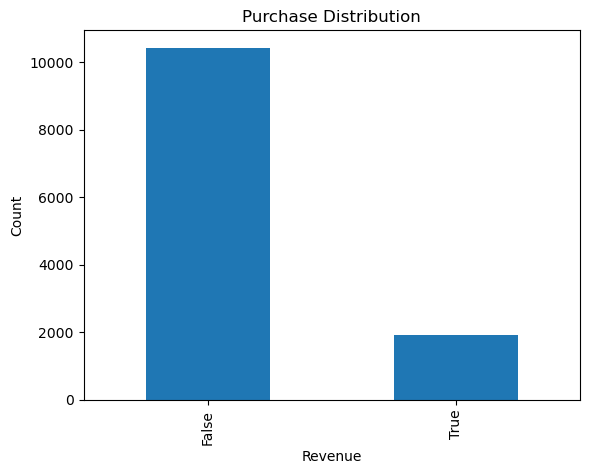

In [12]:
data_set['Revenue'].value_counts().plot(kind='bar')
plt.title("Purchase Distribution")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.show()

In [13]:
data_set.groupby('Revenue')[[
    'Administrative_Duration',
    'Informational_Duration',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues'
]].mean()

,Administrative_Duration,Informational_Duration,ProductRelated_Duration,BounceRates,ExitRates,PageValues
Revenue,,,,,,
False,73.740111,30.236237,1069.987809,0.025317,0.047378,1.975998
True,119.483244,57.611427,1876.209615,0.005117,0.019555,27.264518


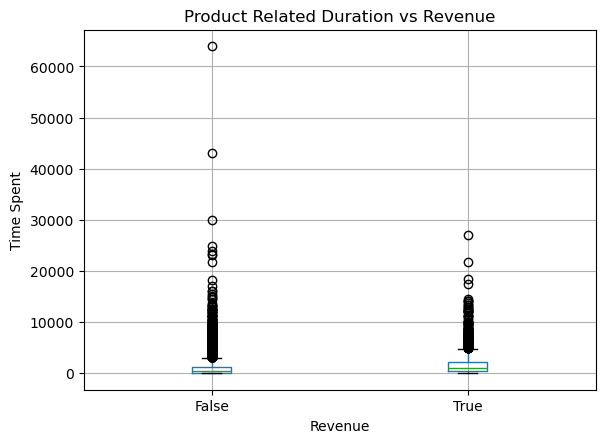

In [14]:
data_set.boxplot(column='ProductRelated_Duration', by='Revenue')
plt.title("Product Related Duration vs Revenue")
plt.suptitle("")
plt.xlabel("Revenue")
plt.ylabel("Time Spent")
plt.show()

In [15]:
data_set_encoded = pd.get_dummies(data_set, drop_first=True)
data_set_encoded.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


In [16]:
from sklearn.model_selection import train_test_split

X = data_set_encoded.drop('Revenue', axis=1)
y = data_set_encoded['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((9864, 26), (2466, 26))

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

c:\Users\Owner\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[2005   50]
 [ 270  141]]
              precision    recall  f1-score   support

       False       0.88      0.98      0.93      2055
        True       0.74      0.34      0.47       411

    accuracy                           0.87      2466
   macro avg       0.81      0.66      0.70      2466
weighted avg       0.86      0.87      0.85      2466



In [19]:
model = LogisticRegression(max_iter=2000, class_weight='balanced')
model.fit(X_train, y_train)

c:\Users\Owner\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
model = LogisticRegression(max_iter=2000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1803  252]
 [ 104  307]]
              precision    recall  f1-score   support

       False       0.95      0.88      0.91      2055
        True       0.55      0.75      0.63       411

    accuracy                           0.86      2466
   macro avg       0.75      0.81      0.77      2466
weighted avg       0.88      0.86      0.86      2466



In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Faster + better solver
model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='liblinear'
)

model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

[[1803  252]
 [ 104  307]]
              precision    recall  f1-score   support

       False       0.95      0.88      0.91      2055
        True       0.55      0.75      0.63       411

    accuracy                           0.86      2466
   macro avg       0.75      0.81      0.77      2466
weighted avg       0.88      0.86      0.86      2466



In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[1979   76]
 [ 192  219]]
              precision    recall  f1-score   support

       False       0.91      0.96      0.94      2055
        True       0.74      0.53      0.62       411

    accuracy                           0.89      2466
   macro avg       0.83      0.75      0.78      2466
weighted avg       0.88      0.89      0.88      2466

